# 03 · The Mosaic Effect — Why a Perfect Redactor Wouldn't Be Enough

> *"In 1990, [Latanya Sweeney](https://dataprivacylab.org/projects/identifiability/paper1.pdf) showed that 87% of US residents could be uniquely identified from {ZIP code, gender, date of birth} alone. None of those facts is sensitive on its own. Together, they're a fingerprint."*

The mosaic effect is the most uncomfortable finding in this whole project: **even if our NER were perfect, the documents we hand to a model would still leak identity**, because the things we are *not* masking — the QUASI identifiers — combine into something unique.

This notebook quantifies that effect against TAB. If a chunky percentage of TAB documents are uniquely identifiable from their quasi-identifier bag, that has design consequences for Phase 3: the pipeline cannot be NER-and-stop. It needs a re-identification check.

---


## Setup


In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter, defaultdict

from anonymisation.data import load_tab
from anonymisation.mosaic import (
    k_anonymity_table,
    normalise_quasi_value,
    min_facts_to_identify,
)

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

QUASI = ("DEM", "DATETIME", "LOC", "QUANTITY")

dataset = load_tab()
# The headline is corpus-wide. TAB ships several annotator rows per doc_id,
# so we union their QUASI mentions into one fingerprint per document.
all_docs = [d for split in dataset for d in dataset[split]]


def facts_by_doc(docs, normalise=True):
    """doc_id -> set of (entity_type, value) QUASI facts, unioned over annotators."""
    by = defaultdict(set)
    for d in docs:
        for em in d["entity_mentions"]:
            if em["identifier_type"] != "QUASI" or em["entity_type"] not in QUASI:
                continue
            val = (normalise_quasi_value(em["entity_type"], em["span_text"])
                   if normalise else em["span_text"].strip().lower())
            if val:
                by[d["doc_id"]].add((em["entity_type"], val))
    return {k: v for k, v in by.items() if v}


doc_facts = facts_by_doc(all_docs)
print(f"{len(all_docs):,} annotator rows -> {len(doc_facts):,} documents with a QUASI fingerprint")

2,208 annotator rows -> 1,268 documents with a QUASI fingerprint


## A realistic re-identification model

For each document we collect the QUASI facts the model is *not* required to mask — demographics, dates, places, quantities — and ask how few of them an attacker needs to single the document out.

Two refinements make the test honest rather than a strict surface-form bound:

1. **Normalise the facts.** `47-year-old`, `aged 47` and `forty-seven` are the same identifying fact; folding them into one (via `normalise_quasi_value`) stops surface variation from inflating apparent uniqueness. This can only make documents look *less* unique — the conservative direction.
2. **Model a smart attacker.** A real adversary doesn't learn facts in the order they appear; they start with the *most discriminating* one. `min_facts_to_identify` reveals the globally-rarest fact first and counts how many are needed before no other document shares them all.

In [2]:
# Per-document fingerprints (normalised), with how many documents share each.
ka = k_anonymity_table(all_docs, normalise=True)
print(f"{len(ka):,} documents with a fingerprint of >= 2 quasi-identifiers")
ka.head(10)

1,268 documents with a fingerprint of >= 2 quasi-identifiers


,doc_id,signature_size,k,signature
0,001-90194,62,1,"((DATETIME, 1973), (DATETIME, 1992), (DATETIME..."
1,001-60027,15,1,"((DATETIME, 15 years), (DATETIME, 1979), (DATE..."
2,001-61863,16,1,"((DATETIME, 1973), (DATETIME, 1997), (DATETIME..."
3,001-104804,13,1,"((DATETIME, 1955), (DATETIME, 1979), (DATETIME..."
4,001-87007,26,1,"((DATETIME, 1 a m), (DATETIME, 1975), (DATETIM..."
5,001-104157,9,1,"((DATETIME, 1961), (DATETIME, 1998), (DATETIME..."
6,001-83398,12,1,"((DATETIME, 1950), (DATETIME, 1999), (DATETIME..."
7,001-107591,14,1,"((DATETIME, 1980), (DATETIME, 1986), (DATETIME..."
8,001-177388,7,1,"((DATETIME, 1971), (DATETIME, 1995), (DATETIME..."
9,001-96795,10,1,"((DATETIME, 1951), (DATETIME, 1994), (DATETIME..."


In [3]:
# Smart attacker: fewest facts needed to single each document out.
items = list(doc_facts.items())
sets = [s for _, s in items]
min_facts = [min_facts_to_identify(fs, sets[:i] + sets[i + 1:])
             for i, (_, fs) in enumerate(items)]

n = len(min_facts)
never = sum(1 for m in min_facts if m is None)
unique = [m for m in min_facts if m is not None]

print(f"Smart attacker over {n:,} documents:")
for k in (1, 2, 3, 5):
    got = sum(1 for m in unique if m <= k)
    print(f"  unique within <= {k} best-chosen fact(s): {got:4,d}  ({100 * got / n:5.1f}%)")
print(f"  median facts to uniqueness: {int(np.median(unique))}")
print(f"  never unique (a superset fingerprint hides them): {never} ({100 * never / n:.1f}%)")

Smart attacker over 1,268 documents:
  unique within <= 1 best-chosen fact(s): 1,029  ( 81.2%)
  unique within <= 2 best-chosen fact(s): 1,184  ( 93.4%)
  unique within <= 3 best-chosen fact(s): 1,224  ( 96.5%)
  unique within <= 5 best-chosen fact(s): 1,242  ( 97.9%)
  median facts to uniqueness: 1
  never unique (a superset fingerprint hides them): 12 (0.9%)


**The headline:** a smart attacker re-identifies **81% of documents from a single quasi-identifier** and **96.5% within three**. Only **12 of 1,268 (0.9%)** survive — and only because another file's facts happen to be a *superset* of theirs, so an attacker holding just their facts still can't separate the two. (That subset case is the honest exception an exact-fingerprint count would miss.) Normalising surface forms rescues no one; *which* fact you know simply matters as much as how many. After every PERSON, date and ID is masked, these documents are still identifiable from the "harmless" details left behind.

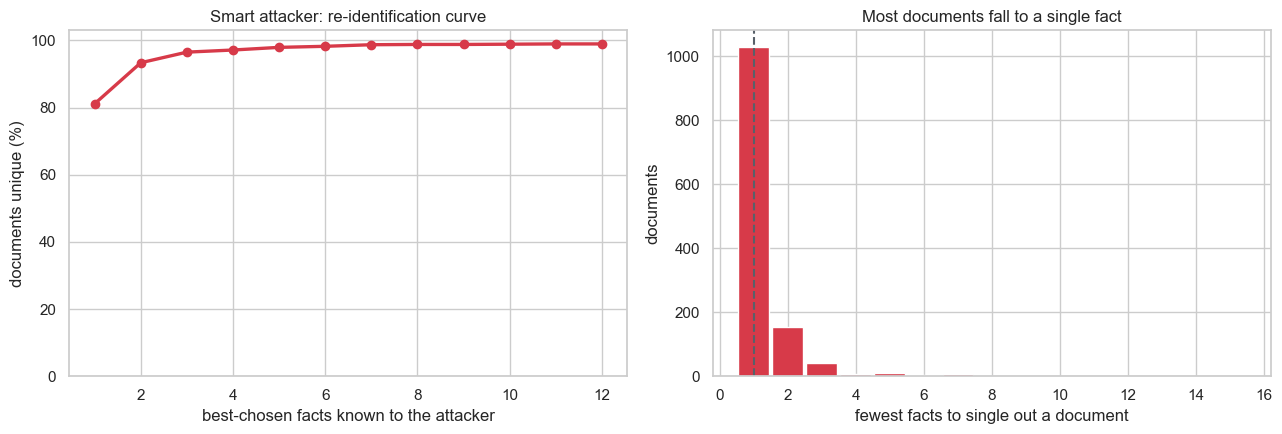

In [4]:
# Re-identification curve + minimum-facts histogram for the smart attacker.
# (Same computation as figures/build_mosaic.py, here on the full corpus.)
def cdf(counts, n_docs, max_n):
    return [100 * sum(1 for c in counts if c is not None and c <= k) / n_docs
            for k in range(1, max_n + 1)]

fig, (axc, axh) = plt.subplots(1, 2, figsize=(13, 4.5))

xs = list(range(1, 13))
axc.plot(xs, cdf(min_facts, n, 12), marker="o", color="#d73a49", linewidth=2.4)
axc.set(xlabel="best-chosen facts known to the attacker",
        ylabel="documents unique (%)", ylim=(0, 103),
        title="Smart attacker: re-identification curve")

axh.hist(unique, bins=range(1, max(unique) + 2), align="left",
         color="#d73a49", edgecolor="white", rwidth=0.9)
axh.axvline(np.median(unique), color="#586069", linestyle="--")
axh.set(xlabel="fewest facts to single out a document", ylabel="documents",
        title="Most documents fall to a single fact")

fig.tight_layout()
plt.show()

## What a unique fingerprint actually looks like

Numbers are abstract. Pulling out one of the k=1 fingerprints makes the risk concrete.


In [5]:
unique_docs = ka[ka["k"] == 1].head(3)
for _, row in unique_docs.iterrows():
    print(f"Document: {row['doc_id']}")
    print(f"Fingerprint size: {row['signature_size']} quasi-identifiers")
    print(f"k = {row['k']} (uniquely identifiable)")
    print("Fingerprint:")
    for et, span in row["signature"][:8]:
        print(f"  [{et}]  {span}")
    if len(row["signature"]) > 8:
        print(f"  ... +{len(row['signature']) - 8} more")
    print("─" * 60)


Document: 001-90194
Fingerprint size: 62 quasi-identifiers
k = 1 (uniquely identifiable)
Fingerprint:
  [DATETIME]  1973
  [DATETIME]  1992
  [DATETIME]  1993
  [DATETIME]  1994
  [DATETIME]  1995
  [DATETIME]  1996
  [DATETIME]  1997
  [DATETIME]  1998
  ... +54 more
────────────────────────────────────────────────────────────
Document: 001-60027
Fingerprint size: 15 quasi-identifiers
k = 1 (uniquely identifiable)
Fingerprint:
  [DATETIME]  15 years
  [DATETIME]  1979
  [DATETIME]  1980
  [DATETIME]  1981
  [DATETIME]  1982
  [DATETIME]  1984
  [DATETIME]  1988
  [DATETIME]  1990
  ... +7 more
────────────────────────────────────────────────────────────
Document: 001-61863
Fingerprint size: 16 quasi-identifiers
k = 1 (uniquely identifiable)
Fingerprint:
  [DATETIME]  1973
  [DATETIME]  1997
  [DATETIME]  1998
  [DATETIME]  1999
  [DATETIME]  2000
  [DATETIME]  2001
  [DATETIME]  2002
  [DATETIME]  2003
  ... +8 more
────────────────────────────────────────────────────────────


## What singles out one document

The attack is concrete. Take a single document, drop every DIRECT identifier (perfect redaction), and find the rarest leftover fact. Usually that one fact — an unusual town, an uncommon occupation — already appears in no other file, so it singles the document out on its own. No name required.

In [6]:
# Walk one document: which single fact singles it out?
import random
random.seed(0)

by_id = dict(items)
one_fact_ids = [items[i][0] for i, m in enumerate(min_facts) if m == 1]
target_id = random.choice(one_fact_ids)
target = by_id[target_id]
others = [s for did, s in items if did != target_id]

freq = Counter()
for s in others:
    freq.update(s & target)
rarest = min(target, key=lambda f: freq.get(f, 0))

print(f"Document {target_id} carries {len(target)} quasi-identifiers.")
print(f"The rarest, {rarest}, appears in {freq.get(rarest, 0)} other documents —")
print("so on its own it singles this document out, even after a perfect redaction.")

Document 001-108670 carries 21 quasi-identifiers.
The rarest, ('DEM', 'bavarian'), appears in 0 other documents —
so on its own it singles this document out, even after a perfect redaction.


## So what?

Three implications for the pipeline design:

1. **NER alone is structurally insufficient.** Even a 100%-recall NER over DIRECT identifiers leaves a re-identifiable document if it doesn't also touch QUASI mentions. Phase 3 must include a mosaic-risk scorer.

2. **Generalisation, not just removal, is the right fix.** The textbook answer is to *generalise* QUASI fields — turn `47-year-old` into `40–50`, `Plovdiv` into `southern Bulgaria`, `nurse` into `healthcare professional`. That gets harder to do automatically as the field becomes more open-ended.

3. **The threshold is a policy decision, not a technical one.** k≥5 is the textbook rule, but legal documents have many QUASI mentions and reaching k=5 typically means generalising heavily — at the cost of the document becoming useless for the AI task. The pipeline needs a tunable risk dial that the firm can set, not a hard-coded threshold.

These are exactly the questions Phase 3 is designed to answer. For now, the takeaway is the size of the gap: a non-trivial share of TAB documents would survive even a *perfect* NER pass and remain uniquely identifiable.


## Caveats to call out in the writeup

- **The haystack is TAB, not the world.** Uniqueness is measured *within* 1,268 ECHR cases. A real attacker matches against a larger, noisier population, which would move the absolute rates — the open item this analysis doesn't close.
- **Normalisation is deliberately conservative.** It folds obvious surface variants (`aged 47` ~ `47-year-old`) but keeps head nouns (`three children` != `three convictions`), so it never *manufactures* uniqueness — if anything it understates it.
- **The greedy attacker is an upper bound on the true minimum.** Finding the smallest identifying fact-set exactly is set-cover (NP-hard); `min_facts_to_identify` approximates it rarest-first, so the real minimum is <= what we report — re-identification is at least this easy.
- **We didn't try to *defeat* the mosaic here.** Generalisation and suppression are Phase 3's job; this notebook only sizes the problem.